# Sales and Profit Analysis Across Regions and Categories

SQL is used for the analysis, while Python is used to connect to MySQL, display query results, and create visualizations.

In [1]:
%pip install pandas sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\anarrasulzada\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

In [11]:
connection_url = URL.create(
    "mysql+pymysql",
    username="superstore_user",
    password="Mayil1234!",
    host="localhost",
    port=3306,
    database="store_db"
)

engine = create_engine(connection_url)

In [12]:
with engine.connect() as conn:
    result = conn.execute(text("select database();"))
    print(result.scalar())

store_db


### Checking the database connection

In [13]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from orders;"))
    print(result.scalar())

9994


## SQL query results into Python

The analysis stays in MySQL. I used Python only to retrieve the query results as DataFrames and display or visualize them.

### Q1: A profile of the orders table

In [14]:
q1 = """
select
    count(*) as total_rows,
    count(distinct customer_id) as unique_customers,
    count(distinct product_id) as unique_products,
    min(order_date) as first_order_date,
    max(order_date) as latest_order_date
from orders;
"""

q1_result = pd.read_sql(q1, engine)

q1_result

,total_rows,unique_customers,unique_products,first_order_date,latest_order_date
0,9994,793,1862,2014-01-03,2017-12-30


### Q2: Checking null values across all columns

In [15]:
q2 = """
    select
    count(*) - count(row_id) as row_id_nulls,
    count(*) - count(order_id) as order_id_nulls,
    count(*) - count(order_date) as order_date_nulls,
    count(*) - count(ship_date) as ship_date_nulls,
    count(*) - count(ship_mode) as ship_mode_nulls,
    count(*) - count(customer_id) as customer_id_nulls,
    count(*) - count(customer_name) as customer_name_nulls,
    count(*) - count(segment) as segment_nulls,
    count(*) - count(country) as country_nulls,
    count(*) - count(city) as city_nulls,
    count(*) - count(state) as state_nulls,
    count(*) - count(postal_code) as postal_code_nulls,
    count(*) - count(region) as region_nulls,
    count(*) - count(product_id) as product_id_nulls,
    count(*) - count(category) as category_nulls,
    count(*) - count(sub_category) as sub_category_nulls,
    count(*) - count(product_name) as product_name_nulls,
    count(*) - count(sales) as sales_nulls,
    count(*) - count(quantity) as quantity_nulls,
    count(*) - count(discount) as discount_nulls,
    count(*) - count(profit) as profit_nulls
from orders;
"""
q2_result = pd.read_sql(q2, engine)
q2_result

,row_id_nulls,order_id_nulls,order_date_nulls,ship_date_nulls,ship_mode_nulls,customer_id_nulls,customer_name_nulls,segment_nulls,country_nulls,city_nulls,...,postal_code_nulls,region_nulls,product_id_nulls,category_nulls,sub_category_nulls,product_name_nulls,sales_nulls,quantity_nulls,discount_nulls,profit_nulls
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Q3: Checking duplicate order lines

In [16]:
q3 = """
    select order_id, product_id, count(*) as duplicate_count
from orders
group by order_id, product_id
having count(*) > 1
order by duplicate_count desc;
"""
q3_result = pd.read_sql(q3, engine)
q3_result

,order_id,product_id,duplicate_count
0,CA-2016-129714,OFF-PA-10001970,2
1,US-2016-123750,TEC-AC-10004659,2
2,CA-2016-137043,FUR-FU-10003664,2
3,CA-2017-152912,OFF-ST-10003208,2
4,US-2014-150119,FUR-CH-10002965,2
5,CA-2015-103135,OFF-BI-10000069,2
6,CA-2017-118017,TEC-AC-10002006,2
7,CA-2016-140571,OFF-PA-10001954,2


### Q4: Average shipping time by ship mode

In [19]:
q4 = """
    select ship_mode,
    round(avg(datediff(ship_date, order_date)), 2) as avg_days_to_ship
from orders
group by ship_mode
order by avg_days_to_ship;
"""
q4_result = pd.read_sql(q4, engine)
q4_result

,ship_mode,avg_days_to_ship
0,Same Day,0.04
1,First Class,2.18
2,Second Class,3.24
3,Standard Class,5.01


### Q5: Comparing profit across regions and product groups

In [23]:
q5 = """
select region, category, sub_category,
    round(sum(sales), 2) as total_sales,
    round(sum(profit), 2) as total_profit,
    round(sum(profit) / sum(sales) * 100, 2) as profit_margin
from orders
group by region, category, sub_category
order by total_profit;
"""
q5_result = pd.read_sql(q5, engine)
q5_result

,region,category,sub_category,total_sales,total_profit,profit_margin
0,East,Furniture,Tables,39139.81,-11025.38,-28.17
1,South,Furniture,Tables,43916.19,-4623.06,-10.53
2,Central,Furniture,Furnishings,15254.37,-3906.22,-25.61
3,Central,Furniture,Tables,39154.97,-3559.65,-9.09
4,Central,Office Supplies,Appliances,23582.03,-2638.62,-11.19
...,...,...,...,...,...,...
63,Central,Technology,Copiers,37259.57,15608.84,41.89
64,West,Office Supplies,Binders,55961.11,16096.80,28.76
65,West,Technology,Accessories,61114.12,16484.60,26.97
66,East,Technology,Copiers,53219.46,17022.84,31.99


### Q6: Comparing the most and least profitable sub-categories

In [24]:
q6 = """
select 'top 5' as profit_group, sub_category, total_profit
from (
    select
        sub_category,
        round(sum(profit), 2) as total_profit
    from orders
    group by sub_category
    order by total_profit desc
    limit 5
) as top_categories
union all
select 'bottom 5' as profit_group, sub_category, total_profit
from (
    select
        sub_category,
        round(sum(profit), 2) as total_profit
    from orders
    group by sub_category
    order by total_profit
    limit 5
) as bottom_categories;
"""
q6_result = pd.read_sql(q6, engine)
q6_result

,profit_group,sub_category,total_profit
0,top 5,Copiers,55617.82
1,top 5,Phones,44515.73
2,top 5,Accessories,41936.64
3,top 5,Paper,34053.57
4,top 5,Binders,30221.76
5,bottom 5,Tables,-17725.48
6,bottom 5,Bookcases,-3472.56
7,bottom 5,Supplies,-1189.10
8,bottom 5,Fasteners,949.52
9,bottom 5,Machines,3384.76


### Q7: Checking profit across different discount levels

In [29]:
q7 = """
select
    case
        when discount = 0 then '0%%'
        when discount <= 0.20 then '1-20%%'
        when discount <= 0.40 then '21-40%%'
        else '41%%+'
    end as discount_band,
    count(distinct order_id) as order_count,
    round(avg(profit), 2) as avg_profit,
    round(sum(profit), 2) as total_profit
from orders
group by discount_band
order by
    case discount_band
        when '0%%' then 1
        when '1-20%%' then 2
        when '21-40%%' then 3
        else 4
    end;
"""

q7_result = pd.read_sql(q7, engine)
q7_result

,discount_band,order_count,avg_profit,total_profit
0,0%,2644,66.90,320987.60
1,1-20%,2507,26.50,100785.47
2,21-40%,400,-77.86,-35817.47
3,41%+,737,-106.71,-99558.59


### Q8: Yearly sales growth

In [30]:
q8 = """
with yearly_sales as (
    select year(order_date) as order_year,
        round(sum(sales), 2) as total_sales
    from orders
    group by year(order_date)
)

select order_year, total_sales,
    lag(total_sales) over (order by order_year) as previous_year_sales,
    round(
        total_sales - lag(total_sales) over (order by order_year), 2
    ) as sales_change,
    round(
        (total_sales - lag(total_sales) over (order by order_year))
        / lag(total_sales) over (order by order_year) * 100, 2
) as yoy_change_pct
from yearly_sales
order by order_year;
"""
q8_result = pd.read_sql(q8, engine)
q8_result

,order_year,total_sales,previous_year_sales,sales_change,yoy_change_pct
0,2014,484247.50,NaN,NaN,NaN
1,2015,470532.51,484247.50,-13714.99,-2.83
2,2016,609205.60,470532.51,138673.09,29.47
3,2017,733215.26,609205.60,124009.66,20.36


### Q9: Sub-categories with negative total profit, and the share of total revenue they represent

In [32]:
q9 = """
with subcategory_profit as (
    select
        sub_category,
        sum(sales) as total_sales,
        sum(profit) as total_profit
    from orders
    group by sub_category
),

overall_sales as (
    select sum(sales) as total_sales
    from orders
)

select
    s.sub_category,
    round(s.total_sales, 2) as total_sales,
    round(s.total_profit, 2) as total_profit,
    round(s.total_sales / o.total_sales * 100, 2) as revenue_share_pct
from subcategory_profit s
cross join overall_sales o
where s.total_profit < 0
order by s.total_profit;
"""
q9_result = pd.read_sql(q9, engine)
q9_result

,sub_category,total_sales,total_profit,revenue_share_pct
0,Tables,206965.53,-17725.48,9.01
1,Bookcases,114880.00,-3472.56,5.00
2,Supplies,46673.54,-1189.10,2.03


### Q10: The most profitable customers

In [33]:
q10 = """
select
    customer_id,
    customer_name,
    count(distinct order_id) as order_count,
    round(sum(sales), 2) as lifetime_sales,
    round(sum(profit), 2) as lifetime_profit,
    round(sum(sales) / count(distinct order_id), 2) as avg_order_value
from orders
group by customer_id, customer_name
order by lifetime_profit desc
limit 10;
"""
q10_result = pd.read_sql(q10, engine)
q10_result

,customer_id,customer_name,order_count,lifetime_sales,lifetime_profit,avg_order_value
0,TC-20980,Tamara Chand,5,19052.22,8981.32,3810.44
1,RB-19360,Raymond Buch,6,15117.34,6976.10,2519.56
2,SC-20095,Sanjit Chand,9,14142.33,5757.41,1571.37
3,HL-15040,Hunter Lopez,6,12873.30,5622.43,2145.55
4,AB-10105,Adrian Barton,10,14473.57,5444.81,1447.36
5,TA-21385,Tom Ashbrook,4,14595.62,4703.79,3648.91
6,CM-12385,Christopher Martinez,4,8954.02,3899.89,2238.51
7,KD-16495,Keith Dawkins,12,8181.26,3038.63,681.77
8,AR-10540,Andy Reiter,6,6608.45,2884.62,1101.41
9,DR-12940,Daniel Raglin,8,8350.87,2869.08,1043.86


### Profit impact of higher discounts (additional)

In [34]:
addition = """
select
    sub_category,
    round(sum(case when discount <= 0.20 then profit else 0 end), 2) as profit_up_to_20,
    round(sum(case when discount > 0.20 then profit else 0 end), 2) as profit_above_20,
    round(avg(case when discount > 0.20 then profit end), 2) as avg_profit_above_20,
    sum(case when discount > 0.20 then 1 else 0 end) as high_discount_lines
from orders
group by sub_category
having high_discount_lines > 0
order by profit_above_20;
"""

addition_result = pd.read_sql(addition, engine)
addition_result

,sub_category,profit_up_to_20,profit_above_20,avg_profit_above_20,high_discount_lines
0,Binders,68732.26,-38510.50,-62.82,613.0
1,Tables,12972.74,-30698.22,-174.42,176.0
2,Machines,32940.11,-29555.35,-557.65,53.0
3,Bookcases,7625.21,-11097.76,-158.54,70.0
4,Appliances,26767.65,-8629.64,-128.80,67.0
5,Chairs,33327.28,-6737.12,-42.64,158.0
6,Phones,50901.52,-6385.79,-58.59,109.0
7,Furnishings,19003.80,-5944.66,-43.08,138.0
8,Copiers,53434.85,2182.98,242.55,9.0


## Visualizations

### Profit by Sub-Category

Comparing total profit across sub-categories and highlighting the loss-making groups.

In [36]:
import matplotlib.pyplot as plt

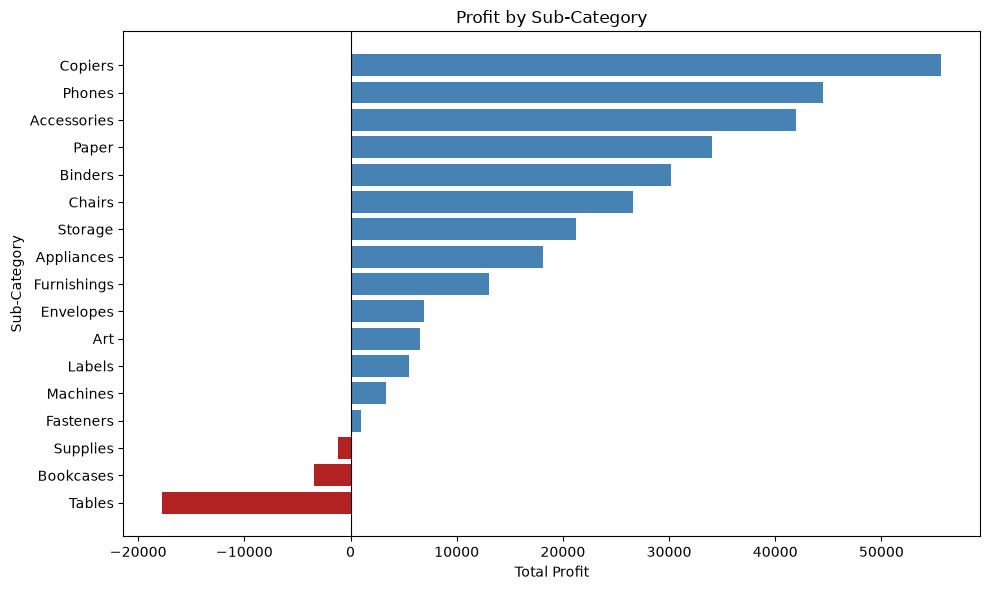

In [37]:
subcat_profit = pd.read_sql("""
select
    sub_category,
    round(sum(profit), 2) as total_profit
from orders
group by sub_category
order by total_profit;
""", engine)

colors = [
    'firebrick' if profit < 0 else 'steelblue'
    for profit in subcat_profit['total_profit']
]

plt.figure(figsize=(10, 6))

plt.barh(
    subcat_profit['sub_category'],
    subcat_profit['total_profit'],
    color=colors
)

plt.axvline(0, color='black', linewidth=0.8)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')

plt.tight_layout()
plt.show()

### Average Profit by Discount Band

Showing how average profit changes as discount levels increase.

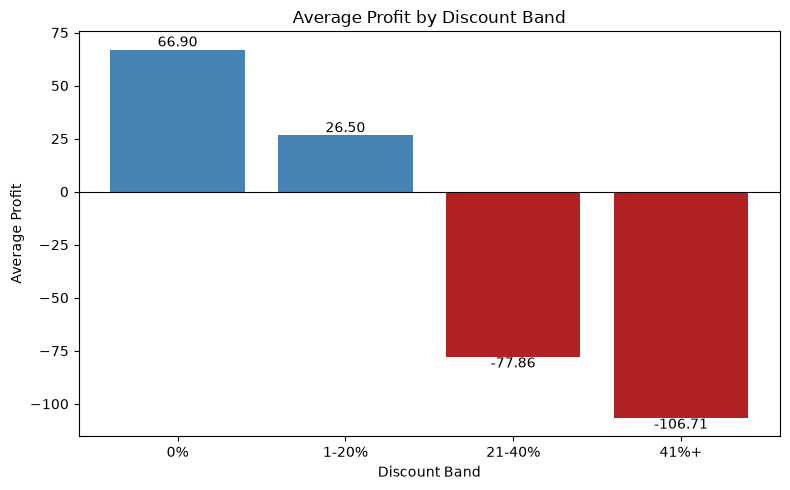

In [38]:
colors = [
    'firebrick' if profit < 0 else 'steelblue'
    for profit in q7_result['avg_profit']
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    q7_result['discount_band'],
    q7_result['avg_profit'],
    color=colors
)

plt.axhline(0, color='black', linewidth=0.8)

plt.title('Average Profit by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit')

for bar, value in zip(bars, q7_result['avg_profit']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.2f}',
        ha='center',
        va='bottom' if value >= 0 else 'top'
    )

plt.tight_layout()
plt.show()

### Sales Momentum Over Time

Tracking annual sales while showing how growth changed from one year to the next.

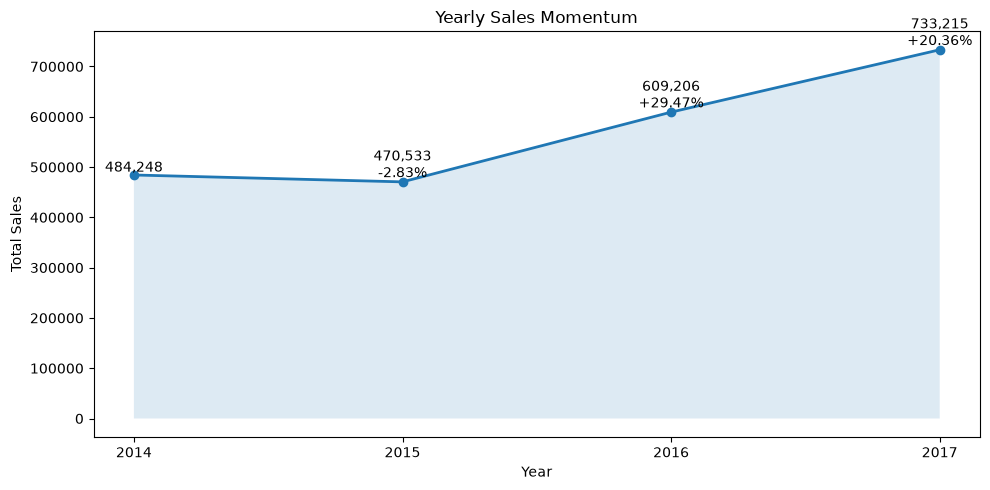

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    q8_result['order_year'],
    q8_result['total_sales'],
    marker='o',
    linewidth=2
)

plt.fill_between(
    q8_result['order_year'],
    q8_result['total_sales'],
    alpha=0.15
)

for _, row in q8_result.iterrows():

    if pd.isna(row['yoy_change_pct']):
        label = f"{row['total_sales']:,.0f}"
    else:
        label = (
            f"{row['total_sales']:,.0f}\n"
            f"{row['yoy_change_pct']:+.2f}%"
        )

    plt.text(
        row['order_year'],
        row['total_sales'],
        label,
        ha='center',
        va='bottom'
    )

plt.title('Yearly Sales Momentum')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.xticks(q8_result['order_year'])

plt.tight_layout()
plt.show()

### Customer Profit Map

Comparing customer sales and profit while using bubble size to represent order frequency.

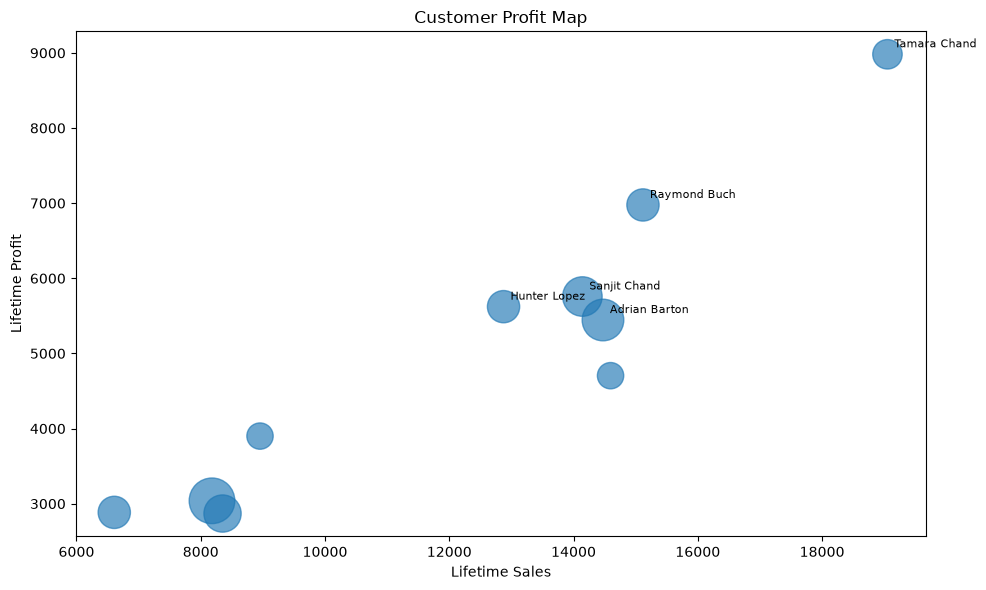

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    q10_result['lifetime_sales'],
    q10_result['lifetime_profit'],
    s=q10_result['order_count'] * 90,
    alpha=0.65
)

top_customers = q10_result.head(5)

for _, row in top_customers.iterrows():
    plt.annotate(
        row['customer_name'],
        (row['lifetime_sales'], row['lifetime_profit']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title('Customer Profit Map')
plt.xlabel('Lifetime Sales')
plt.ylabel('Lifetime Profit')

plt.tight_layout()
plt.show()

### Sales Share by Top Sub-Categories

Showing the sales contribution of the top five sub-categories, with the rest grouped as others.

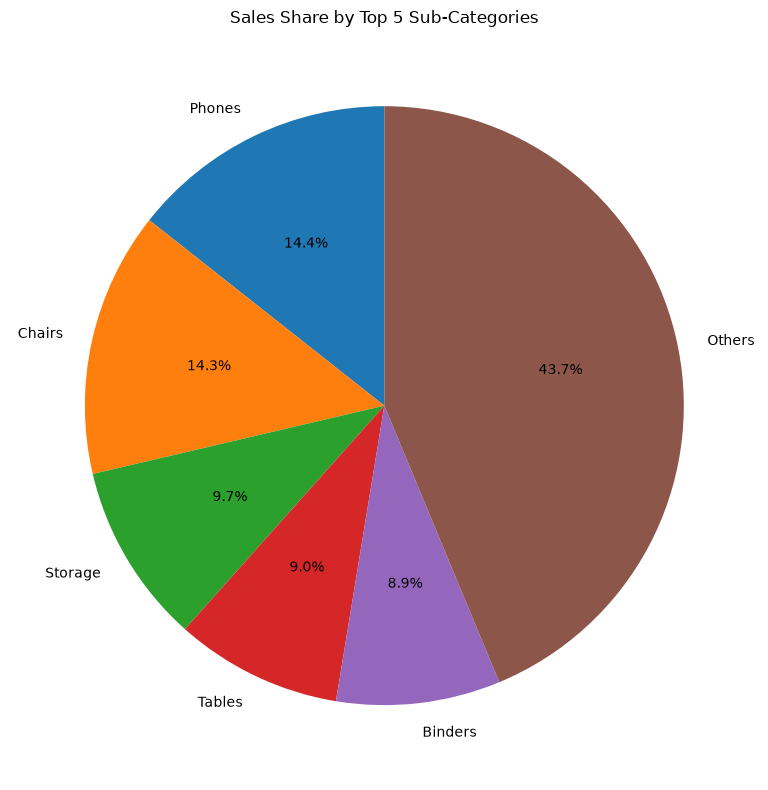

In [42]:
subcat_share = pd.read_sql("""
select
    sub_category,
    round(sum(sales), 2) as total_sales
from orders
group by sub_category
order by total_sales desc;
""", engine)

top5 = subcat_share.head(5).copy()
others_sales = subcat_share.iloc[5:]['total_sales'].sum()

top5.loc[len(top5)] = ['Others', others_sales]

plt.figure(figsize=(8, 8))

plt.pie(
    top5['total_sales'],
    labels=top5['sub_category'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Share by Top 5 Sub-Categories')

plt.tight_layout()
plt.show()